In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import dataloader,TensorDataset
from torchvision import datasets,transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## TRANSFORMING THE IMAGE 

## transform.ToTensor()

### --FIRST WE CONVRT THE PIL IMAGE OR THE NUMPY ARRAY INTO A TENSOR 

### --ALSO WE RESCALE THE PIXEL VALUE FROM **(0-255)** TO **(0-1)** RANGE 

### --SHAPE FORMAT IS CONVERTED INTO (C,H,W)-->CHANNEL , HEIGTH ,WIDTH 

## transform.Normalize()

### --CONVERT THE PIXEL VALUES INTO **[X,Y]** RANGE WHERE THE STANDARD DEVIATION IS **ONE** AND MEAN IS **ZERO**

## SO IN GENERAL USING TRANFORM WE CONVERT THE IMAGE PIXELS INTO RANGE OF **[X,Y]** STANDARDISED RANGE AND CONVERT IT INTO A TENSOR AND THE SHAPE IN THE FORMAT OF (C,H,W)

In [25]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.1307),(0.381))])

## LOADING THE DATASET 

In [26]:
train_dataset=datasets.MNIST(root="./data",train=True,transform=transform,download=True)
test_dataset=datasets.MNIST(root="./data",train=False,transform=transform,download=True)
train_loader = DataLoader( train_dataset,batch_size=64,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=64,shuffle=False)

### --we have loaded the data set , here **train=true** gives the entrie train dataset , while **train = false** gives only the testing dataset

### --here the **transform=transform** ensures every image goes into the transform pipeline

## EDA

### NOT NECESSARY IN PROJECT CODE 

### JUST TO CHECK THE DATA SET IS PROPERLY LOADED OR NOT !

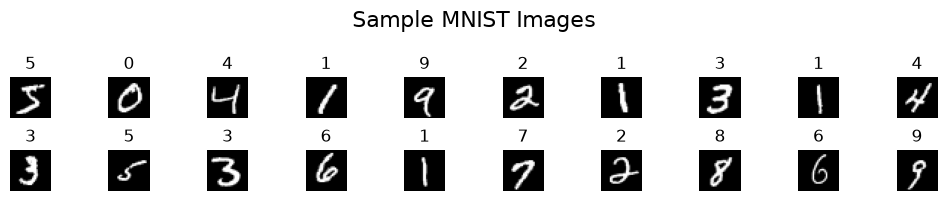

In [27]:
def show_samples(dataset, n=20) :
    plt.figure(figsize=(10, 2)) 
    for i in range(n):
        image, label = dataset[i]
        plt. subplot(2, n//2, i+1)
        plt. imshow(image.squeeze(), cmap='gray' ) 
        plt.title(label) 
        plt.axis("off")
    plt.suptitle("Sample MNIST Images", fontsize=16) 
    plt.tight_layout() 
    plt.show()
show_samples(train_dataset)

## DEFINING A CNN !

In [28]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.fc=nn.Linear(32,10)
        

    def forward(self,x):
        x=self.pool(torch.relu(self.conv1(x)))
        x=self.pool(torch.relu(self.conv2(x)))
        x=self.gap(x)
        x=x.view(-1,32)
        return self.fc(x)

model=CNN()


## nn.Conv2d(x,y,z) --->CREATES AN CONVOLUTIONAL LAYER WITH **X** INPUTS, **Y** FEATURED MAP(OUTPUT'S) , **Z** SIZED KERNELS

## MaxPool2d(a,b) ---> CREATES **A** SIZED WINDOWS AND **B** IS THE SIZE OF THE STRIDE

## nn.Linear(X,Y) ---> CRETEAS THE FULLY CONNECTED LAYER WITH **X** INPUTS AND **Y** OUTPUTS 

## FORWARD

### FIRST WE ARE CALLING CONV1 --> RELU(ACTIVATION FUNCTION)--->POOLING

### NEXT CONV2-->RELU--->POOLING

### NEXT GLOBAL AVERAGE POOLING

### CONVERTING INTO 1D USING VIEW

### RETURNING THE FC LAYER

# Defining Loss Function and Optimizer

In [29]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### --just defining the optimiser and loss function nothing more 

## TRAINING THE MODEL

In [30]:
epochs=10
train_losses=[]

for epoch in range(epochs):
    model.train()
    running_loss=0.0
    for images,labels in train_loader:
        optimizer.zero_grad()
        outputs=model(images)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
    avg_loss=running_loss/len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")



Epoch [1/10], Loss: 1.4385
Epoch [2/10], Loss: 0.7819
Epoch [3/10], Loss: 0.5924
Epoch [4/10], Loss: 0.4819
Epoch [5/10], Loss: 0.4006
Epoch [6/10], Loss: 0.3371
Epoch [7/10], Loss: 0.2896
Epoch [8/10], Loss: 0.2577
Epoch [9/10], Loss: 0.2337
Epoch [10/10], Loss: 0.2161


## each epoch trains with all the images

### model.train() is inbuilt in nn.module , which is used to train the model

### we are setting the gradient as 0 at starting of the each epoch

### finding the loss using loss=criterion(outputs,labels)

### implementing the backprop using loss.backward()

### optimising using optimiser.step()

## MODEL EVALUTION

In [32]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"Accuracy : {accuracy}")
print(f"Precision : {precision}")
print(f"Recall : {recall}")
print(f"F1_Score : {f1}")

Accuracy : 0.9396
Precision : 0.9398921861706482
Recall : 0.9396
F1_Score : 0.9392618927864531


### With torch.no_grad ---> disables the gradient computation because we arent training

## MODEL PREDICTION

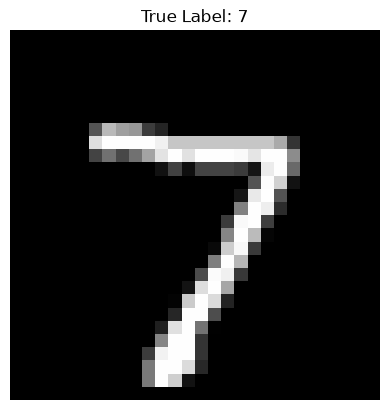

Predicted Class: 7


In [33]:
model.eval()
sample_img, sample_label = test_dataset[0]
plt.imshow(sample_img.squeeze(), cmap='gray')
plt.title(f"True Label: {sample_label}")
plt.axis("off")
plt.show()
sample_tensor = sample_img.unsqueeze(0)


with torch.no_grad():
    output = model(sample_tensor)
    predicted_class = torch.argmax(output, dim=1).item()

print(f"Predicted Class: {predicted_class}")